In [49]:
# STEP 1: CHECK GPU

import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [50]:
# STEP 2: IMPORT LIBRARIES

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

print("Libraries imported successfully!")

Libraries imported successfully!


In [51]:
# STEP 3: SET PARAMETERS

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 28
LEARNING_RATE = 0.0002
BETA1 = 0.5

OUTPUT_DIR = "dcgan_outputs"
GRID_DIR = os.path.join(OUTPUT_DIR, "grids")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

os.makedirs(GRID_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device:", DEVICE)
print("Batch Size:", BATCH_SIZE)
print("Latent Dimension:", LATENT_DIM)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)

Device: cuda
Batch Size: 128
Latent Dimension: 100
Epochs: 28
Learning Rate: 0.0002


In [52]:
# STEP 4: LOAD FASHION-MNIST DATASET

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Dataset loaded successfully!")
print("Number of training images:", len(train_dataset))

Dataset loaded successfully!
Number of training images: 60000


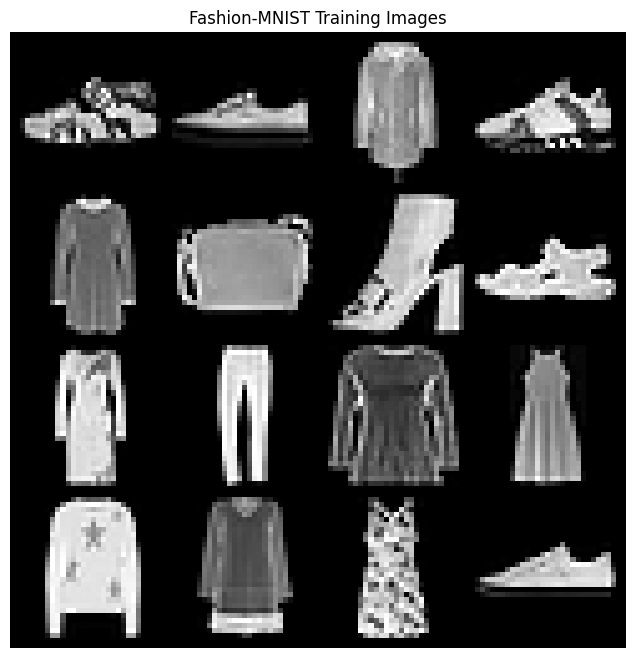

In [53]:
# STEP 5: DISPLAY ORIGINAL FASHION-MNIST IMAGES

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))

grid = make_grid(
    images[:16],
    nrow=4,
    normalize=True,
    padding=2
)

plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)

plt.title("Fashion-MNIST Training Images")
plt.axis("off")
plt.show()

In [54]:
# STEP 6: CREATE THE GENERATOR

class Generator(nn.Module):

    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.fc = nn.Sequential(

            nn.Linear(
                latent_dim,
                128 * 7 * 7
            ),

            nn.BatchNorm1d(
                128 * 7 * 7
            ),

            nn.ReLU(True)
        )

        self.net = nn.Sequential(

            # 7 x 7 -> 14 x 14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),

            # 14 x 14 -> 28 x 28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(
            z.size(0),
            128,
            7,
            7
        )

        x = self.net(x)

        return x


generator = Generator(
    LATENT_DIM
).to(DEVICE)

print(generator)

Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (net): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Tanh()
  )
)


In [55]:
# STEP 7: GENERATE RANDOM NOISE

noise = torch.randn(
    16,
    LATENT_DIM,
    device=DEVICE
)

print("Noise shape:", noise.shape)

Noise shape: torch.Size([16, 100])


In [56]:
# STEP 8: TEST GENERATOR BEFORE TRAINING

with torch.no_grad():
    fake_images = generator(noise)

print("Generated image shape:", fake_images.shape)

Generated image shape: torch.Size([16, 1, 28, 28])


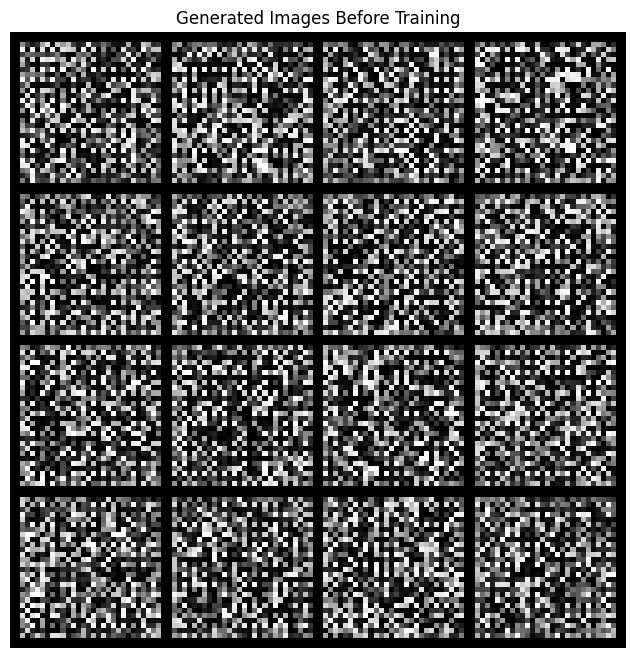

In [57]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# STEP 9: DISPLAY GENERATED IMAGES BEFORE TRAINING

plt.figure(figsize=(8, 8))

grid = make_grid(
    fake_images,
    nrow=4,
    normalize=True,
    padding=2
)

plt.imshow(
    grid.permute(1, 2, 0).squeeze().cpu(),
    cmap="gray"
)

plt.title("Generated Images Before Training")
plt.axis("off")
plt.show()

In [58]:
# STEP 10: CREATE THE DISCRIMINATOR

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.net = nn.Sequential(

            # 28 x 28 -> 14 x 14
            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            # 14 x 14 -> 7 x 7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            )
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 7 * 7,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.net(x)

        x = self.fc(x)

        return x


discriminator = Discriminator().to(DEVICE)

print(discriminator)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=1, bias=True)
    (2): Sigmoid()
  )
)


In [59]:
# STEP 11: TEST DISCRIMINATOR

real_images, labels = next(iter(train_loader))

real_images = real_images.to(DEVICE)

noise = torch.randn(
    4,
    LATENT_DIM,
    device=DEVICE
)

with torch.no_grad():
    fake_images = generator(noise)

with torch.no_grad():

    real_prediction = discriminator(
        real_images[:4]
    )

    fake_prediction = discriminator(
        fake_images
    )

print("Real image predictions:")
print(real_prediction.squeeze().cpu().numpy())

print("\nFake image predictions:")
print(fake_prediction.squeeze().cpu().numpy())

Real image predictions:
[0.27884138 0.44667935 0.38712597 0.32349265]

Fake image predictions:
[0.40969098 0.44021887 0.40994072 0.38768467]


In [60]:
# STEP 12: CREATE LOSS FUNCTION

criterion = nn.BCELoss()

print("Binary Cross Entropy loss created.")

Binary Cross Entropy loss created.


In [61]:
# STEP 13: CREATE OPTIMIZERS

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999)
)

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999)
)

print("Adam optimizers created.")

Adam optimizers created.


In [62]:
# STEP 14: CREATE FIXED RANDOM NOISE

fixed_noise = torch.randn(
    16,
    LATENT_DIM,
    device=DEVICE
)

G_losses = []
D_losses = []

print("Fixed noise created.")

Fixed noise created.


In [63]:
# STEP 15: FUNCTION TO SAVE IMAGE GRIDS

def save_generated_images(epoch):

    generator.eval()

    with torch.no_grad():

        generated = generator(
            fixed_noise
        ).detach().cpu()

    file_path = os.path.join(
        GRID_DIR,
        f"generated_epoch_{epoch:02d}.png"
    )

    save_image(
        generated,
        file_path,
        nrow=4,
        normalize=True,
        padding=2
    )

    generator.train()

    return file_path

In [64]:
# STEP 16: TRAIN THE DCGAN

print("Starting DCGAN training...\n")

for epoch in range(1, EPOCHS + 1):

    generator.train()
    discriminator.train()

    total_G_loss = 0
    total_D_loss = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(DEVICE)

        batch_size = real_images.size(0)

        # ------------------------------
        # Train Discriminator
        # ------------------------------

        optimizer_D.zero_grad()

        real_labels = torch.ones(
            batch_size,
            1,
            device=DEVICE
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=DEVICE
        )

        real_output = discriminator(
            real_images
        )

        d_loss_real = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=DEVICE
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            fake_output,
            fake_labels
        )

        d_loss = (
            d_loss_real +
            d_loss_fake
        )

        d_loss.backward()

        optimizer_D.step()

        # ------------------------------
        # Train Generator
        # ------------------------------

        optimizer_G.zero_grad()

        fake_output = discriminator(
            fake_images
        )

        g_loss = criterion(
            fake_output,
            real_labels
        )

        g_loss.backward()

        optimizer_G.step()

        total_D_loss += d_loss.item()
        total_G_loss += g_loss.item()

    # Average loss
    avg_D_loss = (
        total_D_loss /
        len(train_loader)
    )

    avg_G_loss = (
        total_G_loss /
        len(train_loader)
    )

    D_losses.append(avg_D_loss)
    G_losses.append(avg_G_loss)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f}"
    )

    # Save images every 5 epochs
    if epoch % 5 == 0 or epoch == EPOCHS:

        image_path = save_generated_images(
            epoch
        )

        print(
            "Saved:",
            image_path
        )

print("\nTraining completed!")

Starting DCGAN training...

Epoch [01/28] D Loss: 0.3132 | G Loss: 2.7067
Epoch [02/28] D Loss: 0.3026 | G Loss: 2.7268
Epoch [03/28] D Loss: 0.3465 | G Loss: 2.5624
Epoch [04/28] D Loss: 0.4616 | G Loss: 2.2774
Epoch [05/28] D Loss: 0.5073 | G Loss: 2.1244
Saved: dcgan_outputs/grids/generated_epoch_05.png
Epoch [06/28] D Loss: 0.5257 | G Loss: 2.0801
Epoch [07/28] D Loss: 0.5455 | G Loss: 2.0589
Epoch [08/28] D Loss: 0.5530 | G Loss: 2.0496
Epoch [09/28] D Loss: 0.5598 | G Loss: 2.0598
Epoch [10/28] D Loss: 0.5651 | G Loss: 2.0770
Saved: dcgan_outputs/grids/generated_epoch_10.png
Epoch [11/28] D Loss: 0.5525 | G Loss: 2.1068
Epoch [12/28] D Loss: 0.5600 | G Loss: 2.1078
Epoch [13/28] D Loss: 0.5594 | G Loss: 2.1296
Epoch [14/28] D Loss: 0.5517 | G Loss: 2.1541
Epoch [15/28] D Loss: 0.5577 | G Loss: 2.1630
Saved: dcgan_outputs/grids/generated_epoch_15.png
Epoch [16/28] D Loss: 0.5525 | G Loss: 2.1769
Epoch [17/28] D Loss: 0.5543 | G Loss: 2.1940
Epoch [18/28] D Loss: 0.5433 | G Loss: 2

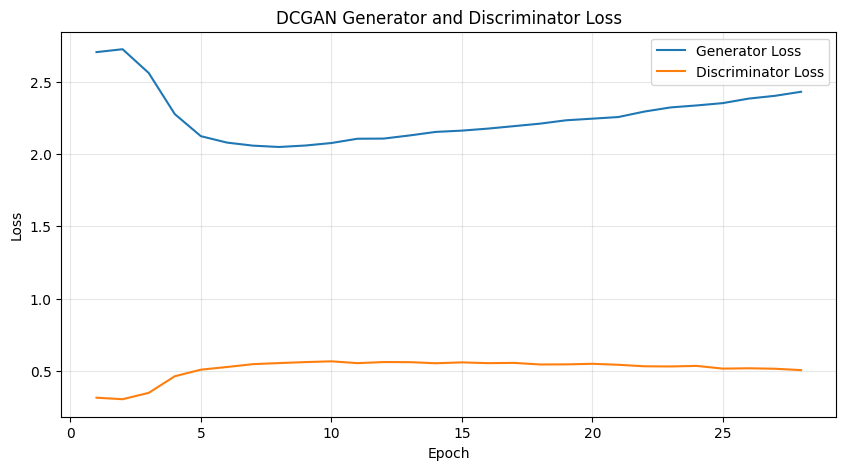

In [67]:
# STEP 17: PLOT GENERATOR AND DISCRIMINATOR LOSS

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    G_losses,
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DCGAN Generator and Discriminator Loss"
)

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "loss_graph.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

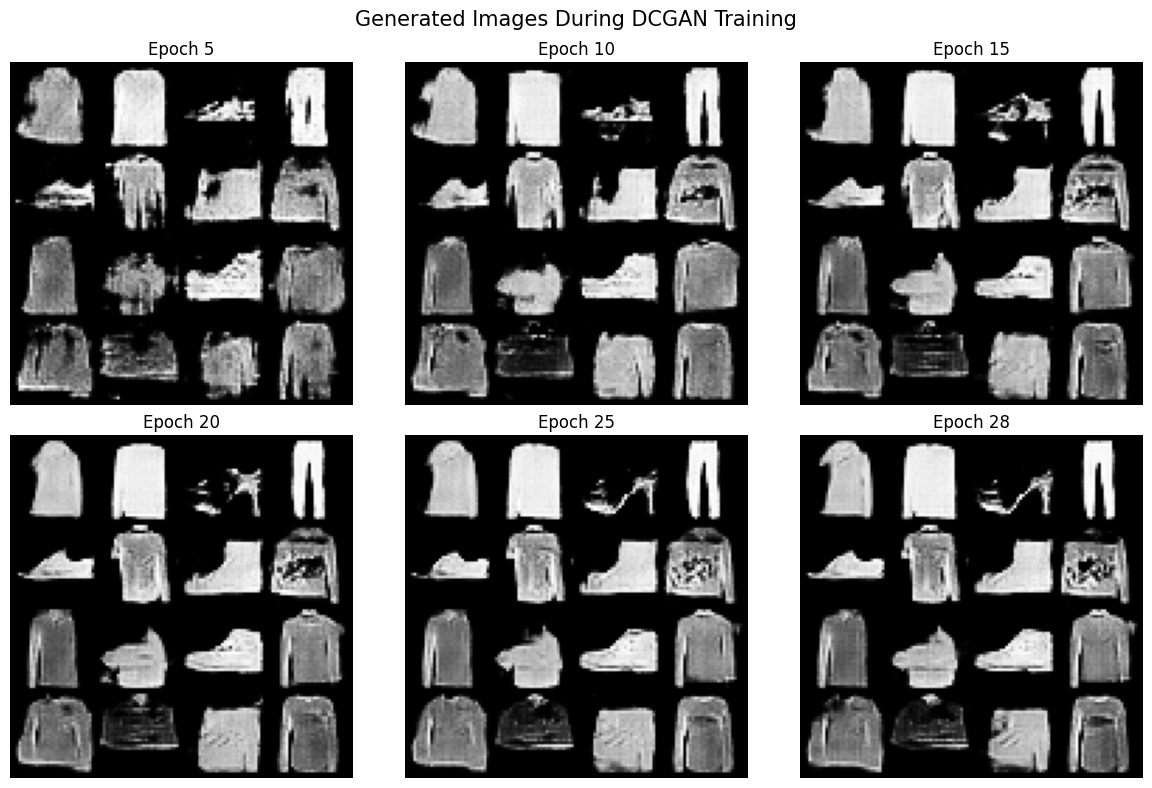

In [68]:
# STEP 18: DISPLAY GENERATED IMAGES FROM DIFFERENT EPOCHS

from PIL import Image

epochs_to_show = [
    5, 10, 15, 20, 25, 28
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, epoch in zip(
    axes.flat,
    epochs_to_show
):

    path = os.path.join(
        GRID_DIR,
        f"generated_epoch_{epoch:02d}.png"
    )

    img = Image.open(path)

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        f"Epoch {epoch}"
    )

    ax.axis("off")

plt.suptitle(
    "Generated Images During DCGAN Training",
    fontsize=15
)

plt.tight_layout()
plt.show()

# OBSERVATION

## Early Epochs

During the early epochs, the generated images are mostly noisy and blurry. Clear clothing shapes are not visible because the Generator has not learned the features of the Fashion-MNIST dataset.

## Improvement During Training

As training progresses, the Generator learns edges, outlines and basic clothing structures. The generated images gradually become more recognizable.

## Recognizable Clothing Shapes

The epoch at which recognizable clothing shapes appear can be identified by comparing the generated image grids from Epoch 5, 10, 15, 20, 25 and 28.

## Image Quality

The image quality does not always improve continuously. GAN training can fluctuate because the Generator and Discriminator are competing against each other.

## Mode Collapse

Mode collapse occurs when the Generator produces very similar images repeatedly. The generated grids can be compared to check whether the generated images have sufficient diversity.

## Training Instability

Some fluctuations in the Generator and Discriminator losses are normal during GAN training. Large fluctuations may indicate instability.

## Conclusion

The DCGAN learns to generate clothing-like images from random noise. As training progresses, the Generator produces increasingly structured images that resemble the Fashion-MNIST dataset.

# QUESTIONS AND ANSWERS

## 1. How does the image change from Epoch 5 to Epoch 25?

From Epoch 5 to Epoch 25, the image becomes clearer and more refined.
The model gradually learns important features from the image.
Unclear or incorrect regions are reduced as training progresses.
By Epoch 25, the image has better-defined features and improved accuracy.
This shows that the model is learning effectively with more training.

## 2. Can you observe instability in training?

Yes, slight instability can be observed in the early stages of training.
As the epochs increase, the model becomes more stable and gives consistent results.
## 3. At which Epoch does clothing-like shape become recognizable?

The clothing-like shape becomes recognizable around Epoch 10–15.
As training continues, the shape becomes clearer and more well-defined
## 4. Does the image continue improving throughout training?

The image improves gradually during the initial stages of training.
After a certain point, the improvement becomes very small and the image remains nearly stable.